In [31]:
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from utilities import check_stationarity

In [32]:
data = yf.download('5296.KL', start='2023-01-01', end='2026-01-03')
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,5296.KL,5296.KL,5296.KL,5296.KL,5296.KL
Date,,,,,
2023-01-03,1.843226,1.861659,1.824794,1.843226,1624100
2023-01-04,1.834010,1.880091,1.834010,1.843226,1706800
2023-01-05,1.834010,1.843226,1.824794,1.824794,1391300
2023-01-06,1.880091,1.880091,1.834010,1.843226,3364000
2023-01-09,1.898523,1.898523,1.880091,1.880091,3771500
...,...,...,...,...,...
2025-12-26,1.550000,1.560000,1.540000,1.550000,7770600
2025-12-29,1.560000,1.580000,1.550000,1.560000,6391900


In [33]:
data.columns = data.columns.droplevel(level='Ticker')
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,1.843226,1.861659,1.824794,1.843226,1624100
2023-01-04,1.834010,1.880091,1.834010,1.843226,1706800
2023-01-05,1.834010,1.843226,1.824794,1.824794,1391300
2023-01-06,1.880091,1.880091,1.834010,1.843226,3364000
2023-01-09,1.898523,1.898523,1.880091,1.880091,3771500


In [34]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 736 entries, 2023-01-03 to 2026-01-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   736 non-null    float64
 1   High    736 non-null    float64
 2   Low     736 non-null    float64
 3   Open    736 non-null    float64
 4   Volume  736 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.5 KB


In [35]:
print(f"Shape of data: {data.shape}")

Shape of data: (736, 5)


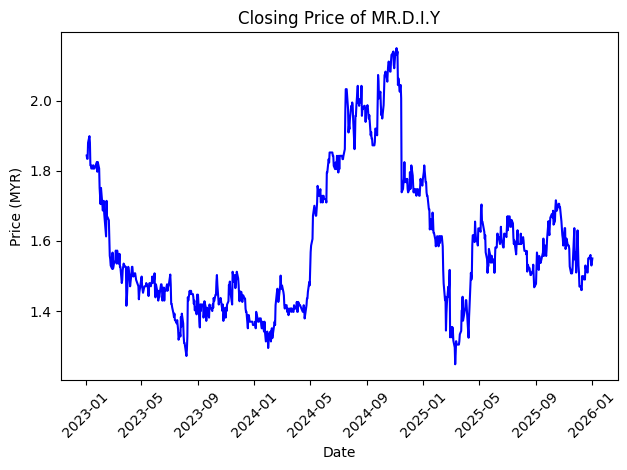

In [36]:
plt.figure()
plt.plot(data.index, data['Close'], color='b')
plt.title('Closing Price of MR.D.I.Y')
plt.ylabel('Price (MYR)')
plt.xlabel('Date')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [37]:
# Features to be stored
features = ['Close', 'High', 'Low', 'Volume']

df = data[features].dropna().rename(
    columns={
        'Close':'close',
        'High':'high',
        'Low':'low',
        'Volume':'volume'
    }
)
df.head()

Price,close,high,low,volume
Date,,,,
2023-01-03,1.843226,1.861659,1.824794,1624100
2023-01-04,1.834010,1.880091,1.834010,1706800
2023-01-05,1.834010,1.843226,1.824794,1391300
2023-01-06,1.880091,1.880091,1.834010,3364000
2023-01-09,1.898523,1.898523,1.880091,3771500


In [38]:
df.to_csv("data/data.csv")